In [ ]:
import pandas as pd
import numpy as np
print("libraries imported successfully!")

libraries imported successfully!


In [ ]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(df.shape)
df.head()

Dataset loaded successfully!
(1000, 21)


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [ ]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Rows and Columns: (1000, 21)

Column Names:
['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'credit_risk']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate        

In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64


In [ ]:
print(df.head())

                status  duration                            credit_history  \
0         ... < 100 DM         6   critical account/other credits existing   
1    0 <= ... < 200 DM        48  existing credits paid back duly till now   
2  no checking account        12   critical account/other credits existing   
3         ... < 100 DM        42  existing credits paid back duly till now   
4         ... < 100 DM        24           delay in paying off in the past   

               purpose  amount                     savings  \
0  domestic appliances    1169  unknown/no savings account   
1  domestic appliances    5951                ... < 100 DM   
2           retraining    2096                ... < 100 DM   
3     radio/television    7882                ... < 100 DM   
4            car (new)    4870                ... < 100 DM   

  employment_duration  installment_rate                  personal_status_sex  \
0      ... >= 7 years                 4                        male : single  

In [ ]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(1000, 21)


In [ ]:
X = df.drop("credit_risk", axis=1)
y = df["credit_risk"]

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (1000, 20)
Target (y): (1000,)


In [ ]:
X = pd.get_dummies(X, drop_first=True)

print("Data converted successfully!")
print("New feature shape:", X.shape)

Data converted successfully!
New feature shape: (1000, 48)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 48)
Testing data: (200, 48)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.77
Accuracy Percentage: 77.0 %


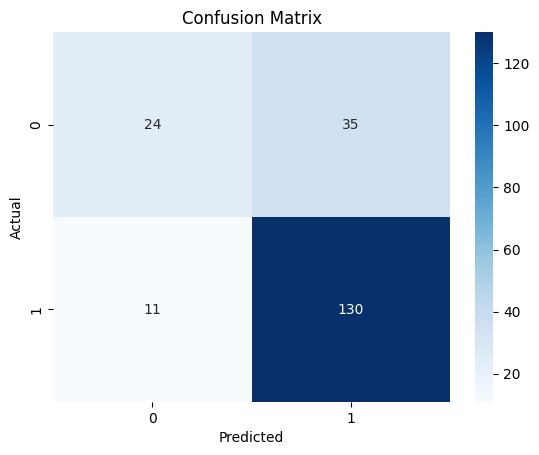

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.766558480586609


In [ ]:
sample_predictions = model.predict(X_test[:10])

print("Actual values:   ", y_test.iloc[:10].values)
print("Predicted values:", sample_predictions)

Actual values:    [0 1 1 1 1 1 1 1 1 1]
Predicted values: [1 1 0 1 1 1 1 1 1 1]


In [ ]:
print("===== Credit Scoring Model Results =====")
print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

===== Credit Scoring Model Results =====
Accuracy: 0.77
ROC-AUC: 0.766558480586609

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.41      0.51        59
           1       0.79      0.92      0.85       141

    accuracy                           0.77       200
   macro avg       0.74      0.66      0.68       200
weighted avg       0.76      0.77      0.75       200



In [ ]:
print("===== Credit Scoring Model Results =====")
print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

===== Credit Scoring Model Results =====
Accuracy: 0.77
ROC-AUC: 0.766558480586609

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.41      0.51        59
           1       0.79      0.92      0.85       141

    accuracy                           0.77       200
   macro avg       0.74      0.66      0.68       200
weighted avg       0.76      0.77      0.75       200



In [ ]:
print("""
CONCLUSION:
The Credit Scoring Model was developed using a Random Forest
classification algorithm. The model was trained using historical
credit-related data and evaluated using accuracy, precision, recall,
F1-score and ROC-AUC.

The model can be used as a machine learning approach to predict
credit risk based on the available financial and personal features.
""")


CONCLUSION:
The Credit Scoring Model was developed using a Random Forest
classification algorithm. The model was trained using historical
credit-related data and evaluated using accuracy, precision, recall,
F1-score and ROC-AUC.

The model can be used as a machine learning approach to predict
credit risk based on the available financial and personal features.

